问题1 

    分析出不同导演电影的好评率，并筛选出TOP20
    
要求：

    ① 计算统计出不同导演的好评率
    ② 通过多系列柱状图，做图表可视化
    
提示：

    ① 好评率 = 好评数 / 评分人数
    ② 可自己设定图表风格
    

问题2 

     统计分析2001-2016年每年评影人数总量
    求出不同剧的评分人数、好评数总和

In [ ]:
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt

In [ ]:
# 读取文件 ,存在编码格式, 默认编码是utf-8
data = pd.read_csv('爱奇艺视频数据.csv', encoding="gbk")
data.info()

### 注：low_memory
pandas读取csv文件默认是按块读取的，即不一次性全部读取；
另外pandas对数据的类型是完全靠猜的，所以pandas每读取一块数据就对csv字段的数据类型进行猜一次，所以有可能pandas在读取不同块时对同一字段的数据类型猜测结果不一致。
low_memory=False 参数设置后，pandas会一次性读取csv中的所有数据，然后对字段的数据类型进行唯一的一次猜测。这样就不会导致同一字段的Mixed types问题了。
但是这种方式真的非常不好，一旦csv文件过大，就会内存溢出；所以推荐用第1中解决方案。 

#### 1.设置read_csv的dtype参数，指定字段的数据类型
pd.read_csv(sio, dtype={"user_id": int, "username": object})
#### 2.设置read_csv的low_memory参数为False
 pd.read_csv(sio, low_memory=False})

In [ ]:
# 读取文件
data = pd.read_csv('爱奇艺视频数据.csv',low_memory=False,encoding="gbk")

In [ ]:
data.info()

In [ ]:
# 读取文件
data = pd.read_csv('爱奇艺视频数据.csv',dtype={"视频ID":object},encoding="gbk")
data.info()

In [23]:
# 查看前几条数据
data.head(3)

,数据获取日期,演员,视频ID,详细链接,剧名,状态,类型,来源平台,整理后剧名,更新时间,...,上映年份,简介,导演,差评数,评分人数,播放量,更新至,总集数,第几季,好评数
0,2016年5月24日,NaN,100,http://www.iqiyi.com/dianshiju/douyu2.html,斗鱼Ⅱ(1-20)全集,已完结,粤语电视剧/偶像剧/言情剧/超清1080P,爱奇艺,斗鱼2,NaN,...,2004.0,在单子杀了阿豹派去强暴语燕的手下而入狱后，众人的生活都有了改变。语燕为了让自己不再是于皓的包...,NaN,2034.0,32722.0,8069526.0,NaN,20.0,2,30688.0
1,2016年5月24日,NaN,1037,http://www.iqiyi.com/dianshiju/jhuxd.html,江湖兄弟(1-32)全集,已完结,粤语电视剧/悬疑剧/年代剧/超清1080P,爱奇艺,江湖兄弟全集,NaN,...,2008.0,1930年代，海龙城首富唐英明用五斗上等珍珠，击败列国商业对手，买得与铁达尼齐名之奥丽号邮轮...,NaN,7291.0,39492.0,70213917.0,NaN,32.0,1,32201.0
2,2016年5月24日,NaN,1573,http://www.iqiyi.com/dianshiju/fmxqj2.html,肥猫寻亲记2(1-30)全集,已完结,粤语电视剧/家庭剧/喜剧,爱奇艺,肥猫寻亲记2全集,NaN,...,2005.0,肥猫经历了几番风雨，终于寻回了他的亲生弟妹们：年轻有为的医生二弟华世杰、大律师三妹婉容、美丽...,NaN,1183.0,10105.0,3310768.0,NaN,30.0,1,8922.0


In [ ]:
data.columns

### 计算统计出不同导演的好评率

In [26]:
data.groupby('导演').sum()[["好评数","评分人数"]]

,好评数,评分人数
导演,,
Exact,375172.0,458543.0
John Fawcett Steve Dimarco Paul Fox,1477942.0,1729878.0
Michael Cuesta,527348.0,604104.0
Michael Dinner,1032245.0,1312847.0
Michael Engler,47804.0,61844.0
...,...,...
龚朝,4634.0,8620.0
龚朝/杨巧文/王伟仁,676160.0,964912.0
龚朝晖,4044245.0,5941895.0


In [24]:
data.groupby('导演')[['好评数','评分人数']].sum()

,好评数,评分人数
导演,,
Exact,375172.0,458543.0
John Fawcett Steve Dimarco Paul Fox,1477942.0,1729878.0
Michael Cuesta,527348.0,604104.0
Michael Dinner,1032245.0,1312847.0
Michael Engler,47804.0,61844.0
...,...,...
龚朝,4634.0,8620.0
龚朝/杨巧文/王伟仁,676160.0,964912.0
龚朝晖,4044245.0,5941895.0


In [28]:
data[['导演','好评数','评分人数']].groupby("导演").sum()

,好评数,评分人数
导演,,
Exact,375172.0,458543.0
John Fawcett Steve Dimarco Paul Fox,1477942.0,1729878.0
Michael Cuesta,527348.0,604104.0
Michael Dinner,1032245.0,1312847.0
Michael Engler,47804.0,61844.0
...,...,...
龚朝,4634.0,8620.0
龚朝/杨巧文/王伟仁,676160.0,964912.0
龚朝晖,4044245.0,5941895.0


In [ ]:
df_q1 = data.groupby('导演').sum()[['好评数','评分人数']]

In [29]:
# 新增好评率:
df_q1['好评率'] = df_q1['好评数']/df_q1['评分人数']
df_q1

,好评数,评分人数,好评率
导演,,,
Exact,375172.0,458543.0,0.818183
John Fawcett Steve Dimarco Paul Fox,1477942.0,1729878.0,0.854362
Michael Cuesta,527348.0,604104.0,0.872942
Michael Dinner,1032245.0,1312847.0,0.786265
Michael Engler,47804.0,61844.0,0.772977
...,...,...,...
龚朝,4634.0,8620.0,0.537587
龚朝/杨巧文/王伟仁,676160.0,964912.0,0.700748
龚朝晖,4044245.0,5941895.0,0.680632


In [30]:
# 并筛选出TOP20
result_q1 = df_q1.sort_values('好评率',ascending=False)[:20]
result_q1

,好评数,评分人数,好评率
导演,,,
王静,5.601448e+06,5.602704e+06,0.999776
萧锋,4.415545e+07,4.416801e+07,0.999716
向灼,3.685386e+06,3.691240e+06,0.998414
乌兰塔娜,1.916524e+07,1.920091e+07,0.998142
徐宗政,3.113422e+06,3.123920e+06,0.996639
欧凡,3.088701e+06,3.100421e+06,0.996220
肖光辉,3.264290e+05,3.284140e+05,0.993956
张国立/罗长安,8.177111e+06,8.230880e+06,0.993467
刘逢声/林峰,3.591638e+06,3.617351e+06,0.992892


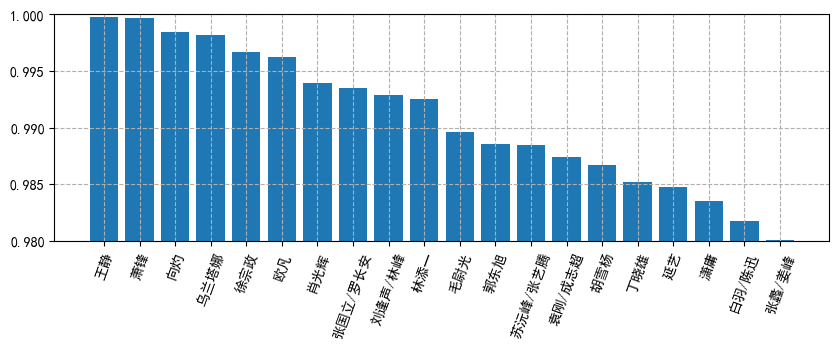

In [34]:
# 设置中文:
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
# 中文负号
plt.rcParams['axes.unicode_minus'] = False

# 设置分别率 为100
plt.rcParams['figure.dpi'] = 100
# 设置大小
plt.rcParams['figure.figsize'] = (10,3)
# 绘制图形
plt.bar(result_q1.index,result_q1['好评率'])
# 设置y轴范围
plt.ylim(0.98,1)
# 设置x轴文字倾斜
plt.xticks(rotation=70)
# 设置网格
plt.grid(True, linestyle='--')

In [ ]:
# 绘制柱状图
result_q1['好评率'].plot(kind='bar',
       color = 'b',
       width = 0.8,
       alpha = 0.4,
       rot = 45,
       grid = True,
       ylim = [0.98,1],
       figsize = (12,4),
       title = '不同导演电影的好评率')

问题2 

    统计分析2001-2016年每年评影人数总量
    求出不同剧的评分人数、好评数总和
    

In [ ]:
data.head(2)

In [ ]:
# 统计分析2001-2016年每年评影人数总量
data.info()

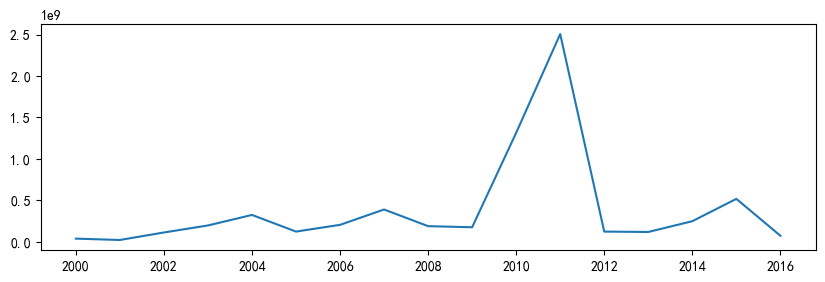

In [36]:
movie_year = data.groupby('上映年份')[['评分人数']].sum()
# 取出大于2000年的数据
movie_year_2000 = movie_year.loc[2000:]
# 绘制面积图
plt.stackplot(movie_year_2000.index,movie_year_2000['评分人数'])

In [37]:
# 求出不同剧的评分人数、好评数总和, 好评数前20绘图
movie_title_group = data.groupby('整理后剧名')[['评分人数','好评数']].sum()
result_title = movie_title_group.sort_values('好评数',ascending=False)[:20]
result_title

,评分人数,好评数
整理后剧名,,
回家的诱惑,1.014866e+09,1.014811e+09
宫锁心玉,9.324091e+08,8.586994e+08
爱情公寓2,5.771680e+08,5.421958e+08
爱情公寓4,4.849908e+08,4.328469e+08
花千骨,5.143373e+08,4.301854e+08
终极1家,3.161218e+08,3.056825e+08
盗墓笔记,3.121707e+08,2.583803e+08
克拉恋人,3.011078e+08,2.560921e+08
天龙8部,2.570178e+08,2.493245e+08


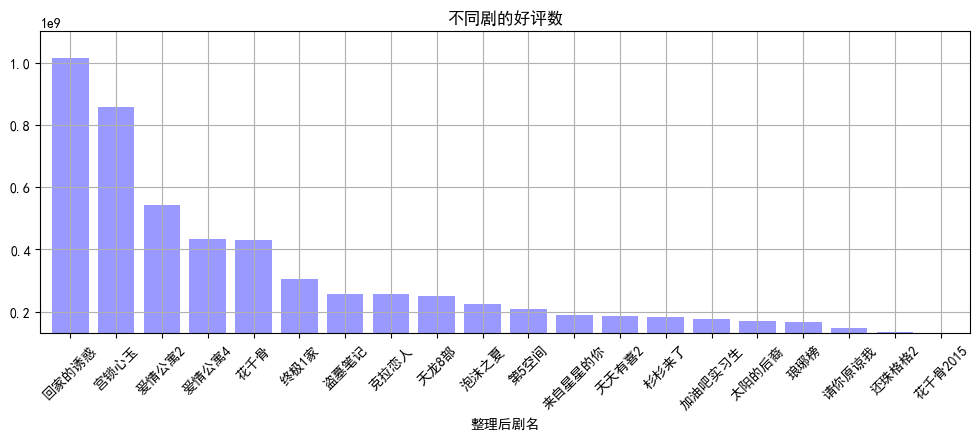

In [38]:
# 绘制柱状图, 以行标签为x轴数据. y的数据为当前列数据
result_title['好评数'].plot(kind='bar',
       color = 'b',
       width = 0.8,
       alpha = 0.4,
       rot = 45,
       grid = True,
       ylim = [1.3e+08,1.1e+09],
       figsize = (12,4),
       title = '不同剧的好评数')